# Starter Notebook: Text Sentiment Classification

This notebook gives a small, runnable starting point for text-based prediction. It uses a tiny synthetic tweet-sentiment dataset about UK weather and global warming so students can focus on the workflow before moving to a real language dataset.

The main ideas are:

- inspect the text and target labels;
- turn tweets into TF-IDF features;
- compare a trivial reference baseline with a conventional text model;
- adapt the same scaffold later for sentiment analysis, topic labels, or real text data.

## Why this example uses tweet sentiment

Tweet sentiment is a useful starter example because it is short, recognisable, and fits the bootcamp theme of feature engineering plus baseline comparison. Here we treat the target as a sentiment label, so the task is a small text-classification problem.

The tweets below are synthetic teaching examples, not a benchmark dataset. They are only meant to demonstrate the workflow.

In [93]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.dummy import DummyClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.svm import SVC

## 1. Create a small tweet-sentiment dataset

Each row contains a short synthetic tweet about UK weather or global warming and a simple sentiment label. In a real project, the labels might come from manual annotation or an existing dataset.

In [43]:
tweet_rows = [
    {'tweet': 'Finally a sunny break in Manchester. The city feels alive when the rain stops.', 'sentiment': 'positive'},
    {'tweet': 'Watching the sun melt into the sea in Aberystwyth.', 'sentiment': 'positive'},
    {'tweet': 'Scary strong winds along the Aberystwyth seafront and rough waves lasted all night.', 'sentiment': 'negative'},    
    {'tweet': 'Another grey wet morning in Leeds. UK weather is exhausting.', 'sentiment': 'negative'},
    {'tweet': 'Love seeing more people talk seriously about climate action after the heatwave.', 'sentiment': 'positive'},
    {'tweet': 'Rain, wind, and cancelled trains again. Classic miserable British weather.', 'sentiment': 'negative'},
    {'tweet': 'A bright spring day in London makes the whole week feel better.', 'sentiment': 'positive'},
    {'tweet': 'The flooding this winter has been frightening. We cannot ignore global warming forever.', 'sentiment': 'negative'},
    {'tweet': 'Clear skies in Edinburgh today. Perfect weather for walking to campus.', 'sentiment': 'positive'},
    {'tweet': 'I am tired of hearing politicians talk climate while nothing actually changes.', 'sentiment': 'negative'},
    {'tweet': 'Great to see new tree planting projects after last summer heat records.', 'sentiment': 'positive'},
    {'tweet': 'This endless cold rain in Birmingham is ruining every plan I make.', 'sentiment': 'negative'},
    {'tweet': 'Warmer weather and cleaner buses would make city life so much better.', 'sentiment': 'positive'},
    {'tweet': 'Another storm warning tonight. The weather feels more chaotic every year.', 'sentiment': 'negative'},
    {'tweet': 'Nice to have a crisp sunny morning in Glasgow for once.', 'sentiment': 'positive'},
    {'tweet': 'Energy bills are rising and the climate debate just makes people more anxious.', 'sentiment': 'negative'},
    {'tweet': 'Encouraging to see schools discussing climate science and practical solutions.', 'sentiment': 'positive'},
    {'tweet': 'Freezing wind and sideways rain again. I have had enough of this weather.', 'sentiment': 'negative'},
    {'tweet': 'A calm dry weekend in Bristol feels like a rare gift.', 'sentiment': 'positive'},
    {'tweet': 'The smoke from summer wildfires abroad makes the climate crisis feel very real.', 'sentiment': 'negative'},
    {'tweet': 'Good to see more homes adding insulation and solar panels after the heatwaves.', 'sentiment': 'positive'},
    {'tweet': 'This damp gloomy forecast is the opposite of motivating.', 'sentiment': 'negative'}
]

df = pd.DataFrame(tweet_rows)
df['word_count'] = df['tweet'].str.split().str.len()
display(df.head())
print('Rows:', len(df))

,tweet,sentiment,word_count
0,Finally a sunny break in Manchester. The city ...,positive,14
1,Watching the sun melt into the sea in Aberystw...,positive,9
2,Scary strong winds along the Aberystwyth seafr...,negative,13
3,Another grey wet morning in Leeds. UK weather ...,negative,10
4,Love seeing more people talk seriously about c...,positive,12


Rows: 22


In [67]:
from pathlib import Path

data_dir = Path('data')
data_dir.mkdir(exist_ok=True)
csv_path = data_dir / 'your_text_dataset.csv'
df.to_csv(csv_path, index=False)
print(f'Saved dataset to {csv_path.resolve()}')

Saved dataset to /Users/cul/work/Teaching/AIbootcamp/data/your_text_dataset.csv


## 2. Inspect the target and a few examples

Before fitting a model, look at the label distribution and read a few examples. This helps you see whether the target looks balanced and whether the tweet wording seems related to sentiment.

,tweet,sentiment
0,Finally a sunny break in Manchester. The city ...,positive
13,Another storm warning tonight. The weather fee...,negative
8,Clear skies in Edinburgh today. Perfect weathe...,positive
1,Watching the sun melt into the sea in Aberystw...,positive
15,Energy bills are rising and the climate debate...,negative


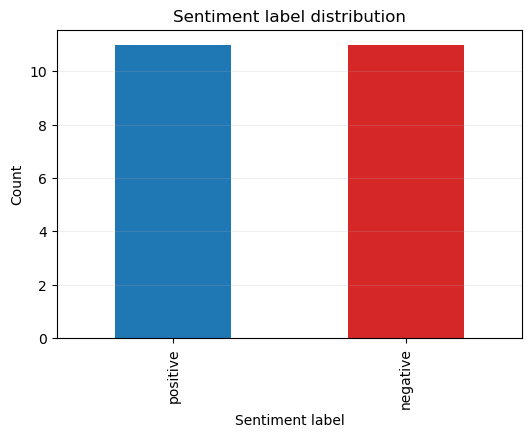

In [68]:
display(df[['tweet', 'sentiment']].sample(5, random_state=42))

df['sentiment'].value_counts().plot(kind='bar', color=['tab:blue', 'tab:red'], figsize=(6, 4))
plt.xlabel('Sentiment label')
plt.ylabel('Count')
plt.title('Sentiment label distribution')
plt.grid(True, axis='y', alpha=0.2)
plt.show()

## 3. Train-test split

We keep a test set separate so we can compare the reference baseline and the text model fairly.

In [79]:
X_train, X_test, y_train, y_test = train_test_split(
    df['tweet'], df['sentiment'], test_size=0.2, random_state=42, stratify=df['sentiment']
)

print('Training rows:', len(X_train))
print('Test rows:', len(X_test))

Training rows: 17
Test rows: 5


## 4. Reference baseline

A trivial reference model for classification can always predict the most frequent class. It is weak, but it tells us whether the text model is learning anything useful from the tweets.

In [80]:
reference_model = DummyClassifier(strategy='most_frequent')
reference_model.fit(np.arange(len(X_train)).reshape(-1, 1), y_train)
reference_predictions = reference_model.predict(np.arange(len(X_test)).reshape(-1, 1))

reference_accuracy = accuracy_score(y_test, reference_predictions)
print('Reference accuracy:', round(reference_accuracy, 3))

Reference accuracy: 0.4


## 5. First conventional baseline: TF-IDF plus linear SVC

This is a practical first model for a text-classification task.
[TfidfVectorizer](https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.TfidfVectorizer.html) turns tweets into numeric features by counting informative words or short phrases and down-weighting terms that appear everywhere.

In this starter version, we also remove common stop words such as "the", "is", and "of" before fitting the model. That helps the interpretation focus more on content words that are actually informative for sentiment.

A linear support vector classifier is often a sensible choice when the feature space is high-dimensional, as it is with TF-IDF, and the number of training examples is small. It learns a separating boundary with a margin between the classes rather than fitting one coefficient set as a probabilistic regression model.

Stemming or lemmatization can also be useful in some text problems, but they are left out here to keep the first workflow lightweight and easy to inspect.

This baseline asks: if we represent tweets with TF-IDF after basic stop-word filtering, can a linear SVC separate positive and negative sentiment reasonably well?

In [102]:
text_model = make_pipeline(
    TfidfVectorizer(ngram_range=(1, 2), min_df=1, stop_words='english'),
    SVC(kernel='linear', probability=True, C=1.0, random_state=42)
)

text_model.fit(X_train, y_train)
text_predictions = text_model.predict(X_test)

text_accuracy = accuracy_score(y_test, text_predictions)

print('TF-IDF + linear SVC accuracy:', round(text_accuracy, 3))
print(classification_report(y_test, text_predictions, zero_division=0))

TF-IDF + linear SVC accuracy: 0.4
              precision    recall  f1-score   support

    negative       0.00      0.00      0.00         3
    positive       0.40      1.00      0.57         2

    accuracy                           0.40         5
   macro avg       0.20      0.50      0.29         5
weighted avg       0.16      0.40      0.23         5



## 5b. Make a manual prediction for a new tweet

Once the model is fitted, you can give it a completely new tweet and ask for a predicted sentiment label.

This is useful when you want to test the model on an example you wrote yourself rather than only looking at the held-out test set.

For a linear SVC, it is often clearer to inspect the decision score or margin rather than calibrated probabilities, especially on a very small dataset.

In [103]:
example_tweet = "Cold wind and rough waves on the Aberystwyth seafront again. The weather feels miserable today."

predicted_label = text_model.predict([example_tweet])[0]
decision_score = float(text_model.decision_function([example_tweet])[0])

print('Example tweet:')
print(example_tweet)
print('\nPredicted sentiment:', predicted_label)
print('Decision score:', round(decision_score, 3))

if decision_score < 0:
    print('A negative score means the example lies on the negative side of the separating boundary.')
else:
    print('A positive score means the example lies on the positive side of the separating boundary.')

Example tweet:
Cold wind and rough waves on the Aberystwyth seafront again. The weather feels miserable today.

Predicted sentiment: negative
Decision score: -0.549
A negative score means the example lies on the negative side of the separating boundary.


## 6. Inspect which words are associated with positive or negative sentiment

One advantage of a linear text model is that we can inspect the fitted coefficients.

After TF-IDF converts words and short phrases into numeric features, the linear SVC learns one coefficient per feature for the separating boundary.
Because we now remove common stop words first, the interpretation is less likely to be dominated by filler words such as "the" or "is" and more likely to highlight content words or short phrases.

- a positive coefficient pushes the model toward one sentiment class;
- a negative coefficient pushes the model toward the other sentiment class.

This is not the same as proving causation, and the coefficients depend on the whole dataset. But it gives a useful first look at model interpretation.

Terms pushing predictions toward 'negative':


,term,coefficient
209,wind,-0.543046
126,rain,-0.482798
196,weather,-0.429576
153,sideways,-0.354703
211,wind sideways,-0.354703
71,freezing,-0.354703
72,freezing wind,-0.354703
129,rain weather,-0.354703
154,sideways rain,-0.354703
113,opposite motivating,-0.333333


Terms pushing predictions toward 'positive':


,term,coefficient
8,better,0.418013
28,city,0.413396
145,sea,0.304831
146,sea aberystwyth,0.304831
193,watching sun,0.304831
103,melt sea,0.304831
171,sun melt,0.304831
102,melt,0.304831
192,watching,0.304831
170,sun,0.304831


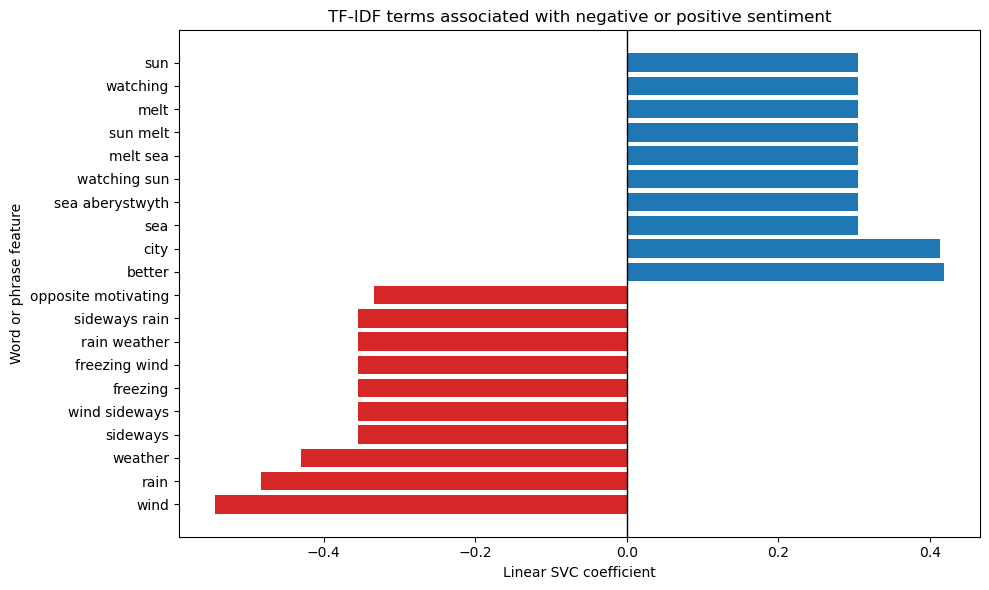

In [104]:
vectorizer = text_model.named_steps['tfidfvectorizer']
svc = text_model.named_steps['svc']

feature_names = vectorizer.get_feature_names_out()
coefficients = np.asarray(svc.coef_.toarray()).ravel()
negative_class, positive_class = svc.classes_[0], svc.classes_[1]

coef_df = pd.DataFrame(
    {
        'term': feature_names,
        'coefficient': coefficients,
    }
).sort_values('coefficient')

negative_terms = coef_df.head(10)
positive_terms = coef_df.tail(10).sort_values('coefficient', ascending=False)

print(f"Terms pushing predictions toward {negative_class!r}:")
display(negative_terms)

print(f"Terms pushing predictions toward {positive_class!r}:")
display(positive_terms)

plot_df = pd.concat([negative_terms, positive_terms], axis=0)
colors = ['tab:red' if value < 0 else 'tab:blue' for value in plot_df['coefficient']]

plt.figure(figsize=(10, 6))
plt.barh(plot_df['term'], plot_df['coefficient'], color=colors)
plt.axvline(0, color='black', linewidth=1)
plt.xlabel('Linear SVC coefficient')
plt.ylabel('Word or phrase feature')
plt.title('TF-IDF terms associated with negative or positive sentiment')
plt.tight_layout()
plt.show()

## 7. Compare predictions with the true labels

A quick table and confusion matrix help you see where the model agrees with the true sentiment labels and where it makes mistakes.

For a linear SVC, the absolute decision score is a useful notion of confidence or margin: larger values mean the model is placing the tweet further from the separating boundary.

,tweet,true_sentiment,predicted_sentiment,correct,margin
0,Good to see more homes adding insulation and s...,positive,positive,True,0.161
1,Energy bills are rising and the climate debate...,negative,positive,False,0.378
2,The flooding this winter has been frightening....,negative,positive,False,0.161
3,I am tired of hearing politicians talk climate...,negative,positive,False,0.434
4,Nice to have a crisp sunny morning in Glasgow ...,positive,positive,True,0.123


Correct predictions: 2 out of 5


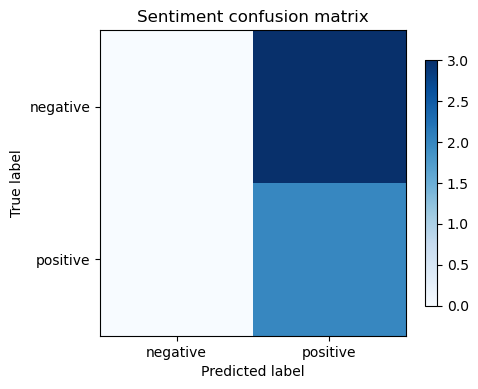

In [101]:
decision_scores = text_model.decision_function(X_test)
margin = np.abs(decision_scores)

results_df = pd.DataFrame(
    {
        'tweet': X_test.values,
        'true_sentiment': y_test.values,
        'predicted_sentiment': text_predictions,
        'correct': y_test.values == text_predictions,
        'margin': np.round(margin, 3),
    }
).reset_index(drop=True)

display(results_df)

print('Correct predictions:', int(results_df['correct'].sum()), 'out of', len(results_df))

cm = confusion_matrix(y_test, text_predictions, labels=text_model.named_steps['svc'].classes_)

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks(np.arange(len(text_model.named_steps['svc'].classes_)))
ax.set_yticks(np.arange(len(text_model.named_steps['svc'].classes_)))
ax.set_xticklabels(text_model.named_steps['svc'].classes_)
ax.set_yticklabels(text_model.named_steps['svc'].classes_)
ax.set_xlabel('Predicted label')
ax.set_ylabel('True label')
ax.set_title('Sentiment confusion matrix')
fig.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()

## 8. What to change for other language tasks

The same scaffold can be adapted for other text problems:

- topic classification: keep TF-IDF features, but predict topic categories instead of sentiment;
- automatic essay scoring: replace the tweets with student responses and switch from classification to regression;
- larger sentiment datasets: keep the same train-test and baseline logic, but swap in a real dataset.

If the task is unsupervised topic modelling, the workflow changes because there is no target variable.
In that case you would usually move away from classification and instead look for groups or themes in the texts.

A practical next step after this notebook is to replace the toy tweet table with your own CSV file while keeping the same TF-IDF plus linear SVC workflow.

## 9. Optional extension: use your own CSV text dataset

If you already have your own text dataset in a CSV file, you can reuse the same workflow.

Update:

- the file path;
- the text column name;
- the target column name.

Then keep the same train-test split, TF-IDF features, and linear SVC model.

In [ ]:
# OPTIONAL EXTENSION
# Keep this flag set to False until you have updated the path and column names.

RUN_REAL_CSV_TEMPLATE = False

if RUN_REAL_CSV_TEMPLATE:
    text_path = 'data/your_text_dataset.csv'
    text_col = 'tweet'
    target_col = 'sentiment'

    df_real = pd.read_csv(text_path)
    X_train_real, X_test_real, y_train_real, y_test_real = train_test_split(
        df_real[text_col],
        df_real[target_col],
        test_size=0.2,
        random_state=42,
        stratify=df_real[target_col],
    )

    model = make_pipeline(
        TfidfVectorizer(ngram_range=(1, 2), stop_words='english'),
        SVC(kernel='linear', probability=True, C=1.0, random_state=42),
    )
    model.fit(X_train_real, y_train_real)
    predictions = model.predict(X_test_real)

    print('Real CSV accuracy:', round(accuracy_score(y_test_real, predictions), 3))
    print(classification_report(y_test_real, predictions, zero_division=0))
else:
    print('Real CSV template is disabled. Set RUN_REAL_CSV_TEMPLATE = True after updating the path and column names.')

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 8014.35it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Embedding + linear SVC accuracy: 0.6
Real CSV accuracy: 0.4


## 10. Takeaways

- Start with a runnable toy text problem before switching to a larger real dataset.
- TF-IDF is a strong first representation for many conventional language tasks.
- Always compare against a trivial reference baseline.
- For tweet sentiment, a sensible first framing here is classification with TF-IDF plus a linear SVC.
- Simple linear text models can often be interpreted by inspecting which words or phrases get positive or negative coefficients.
- Once the workflow works on the toy example, you can reuse the same structure on your own CSV dataset.